<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Projective_Dynamics_and_the_Emergence_of_Quantum_Wave_Equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

k1 = 1.7321, k2 = 0.0000
Theoretical PSC left: 0.7963
Theoretical PSC right: nan


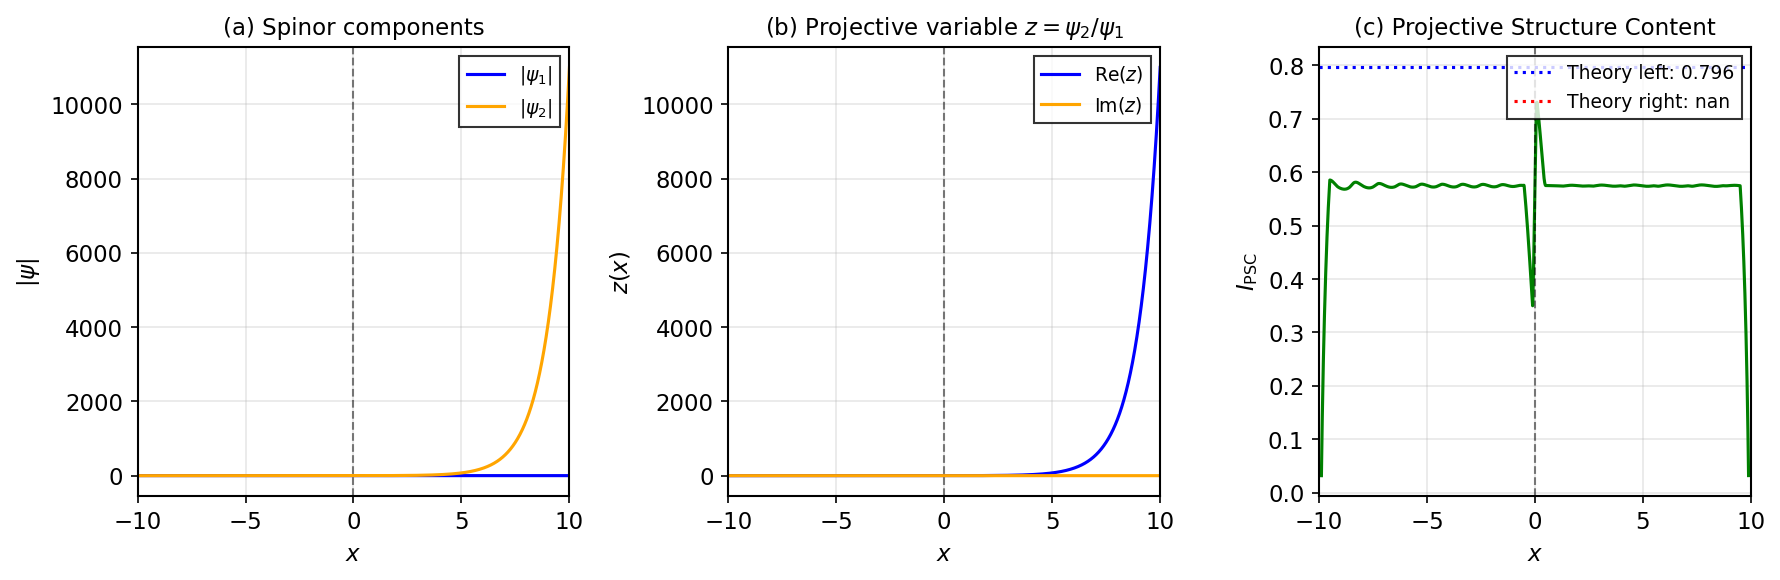

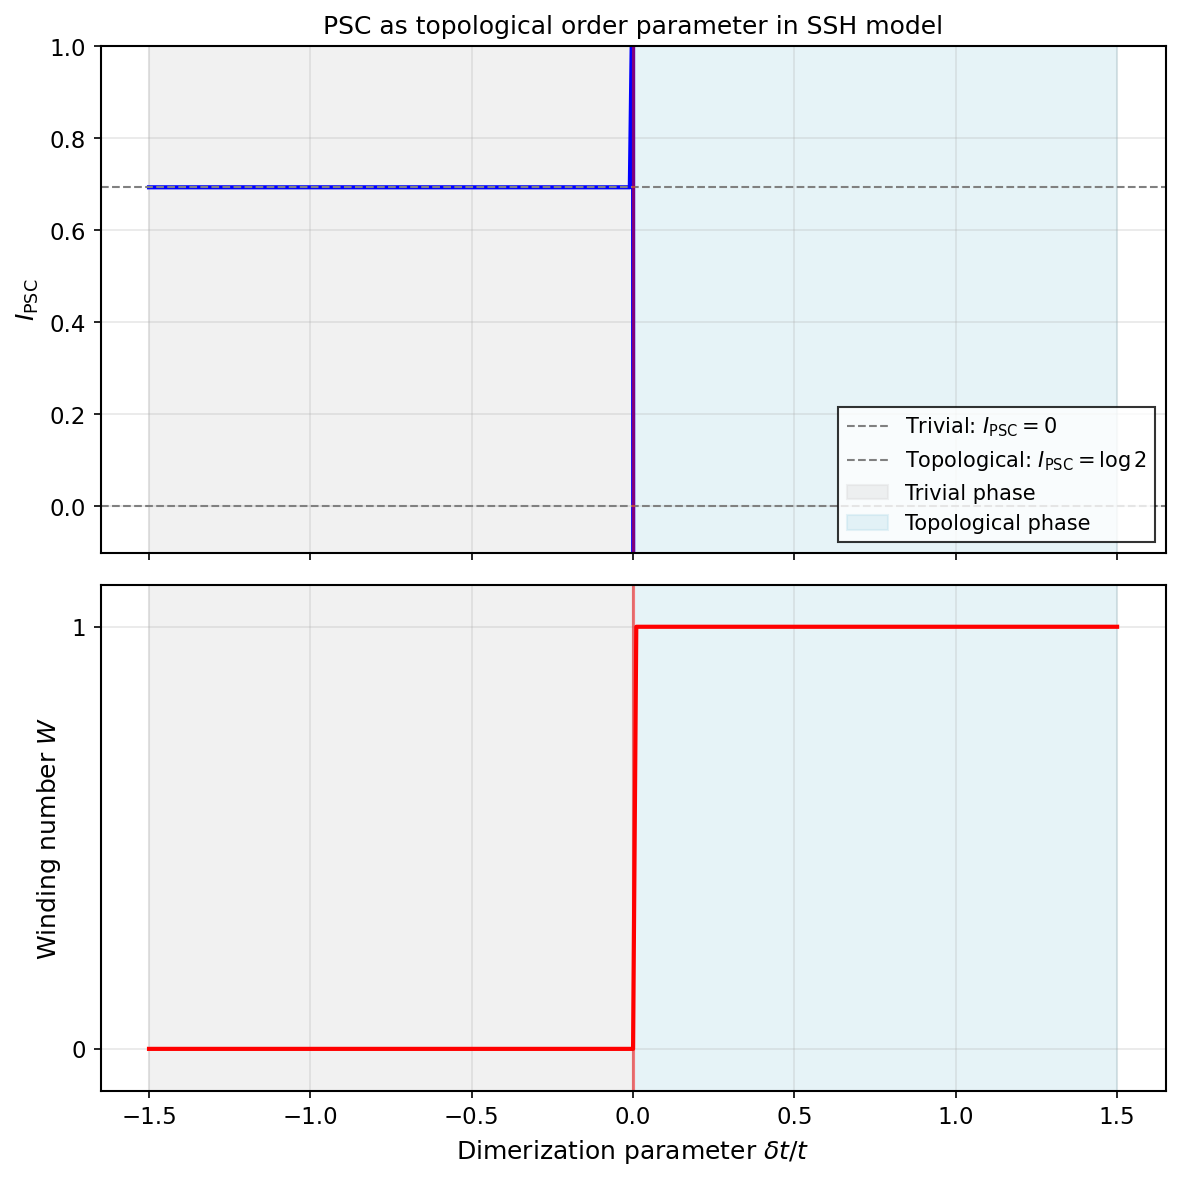

PSC trivial phase: 0.0
PSC topological phase: 0.693147 (log 2)


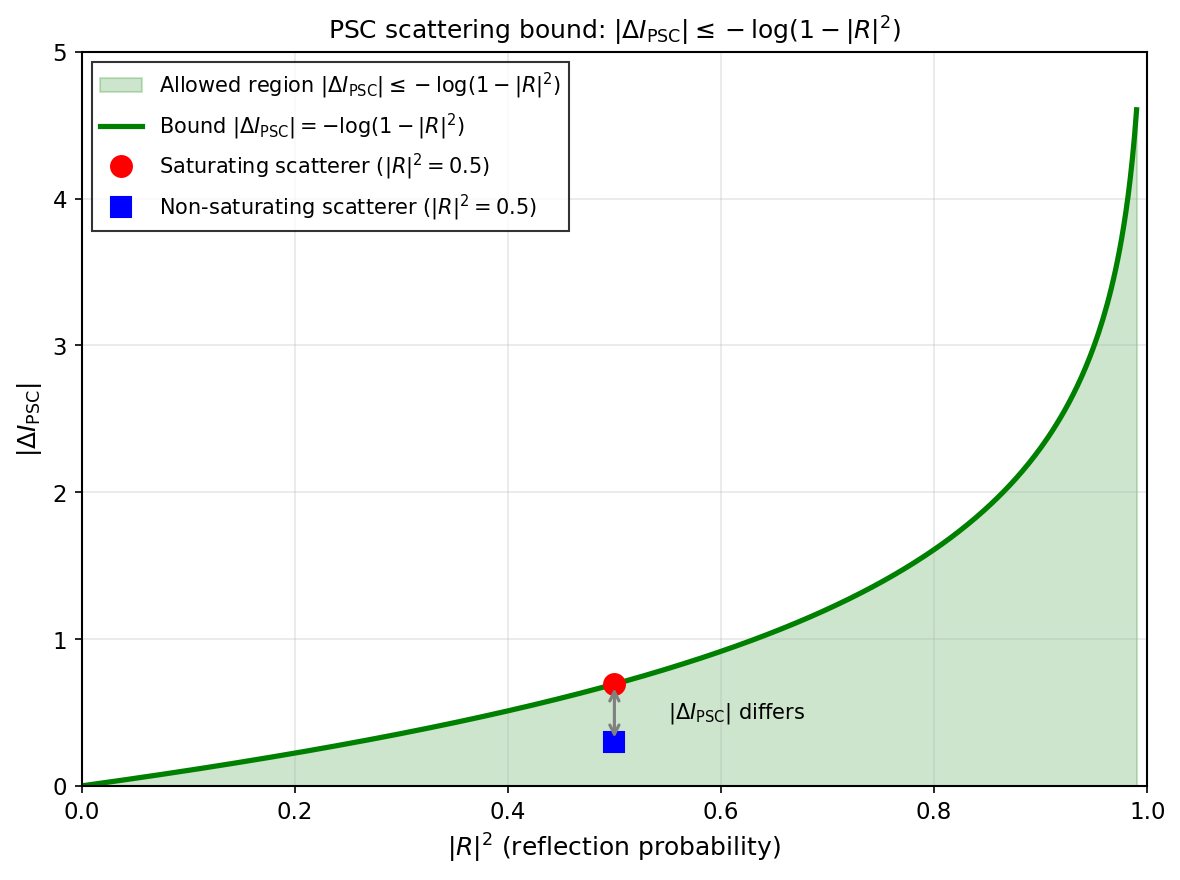

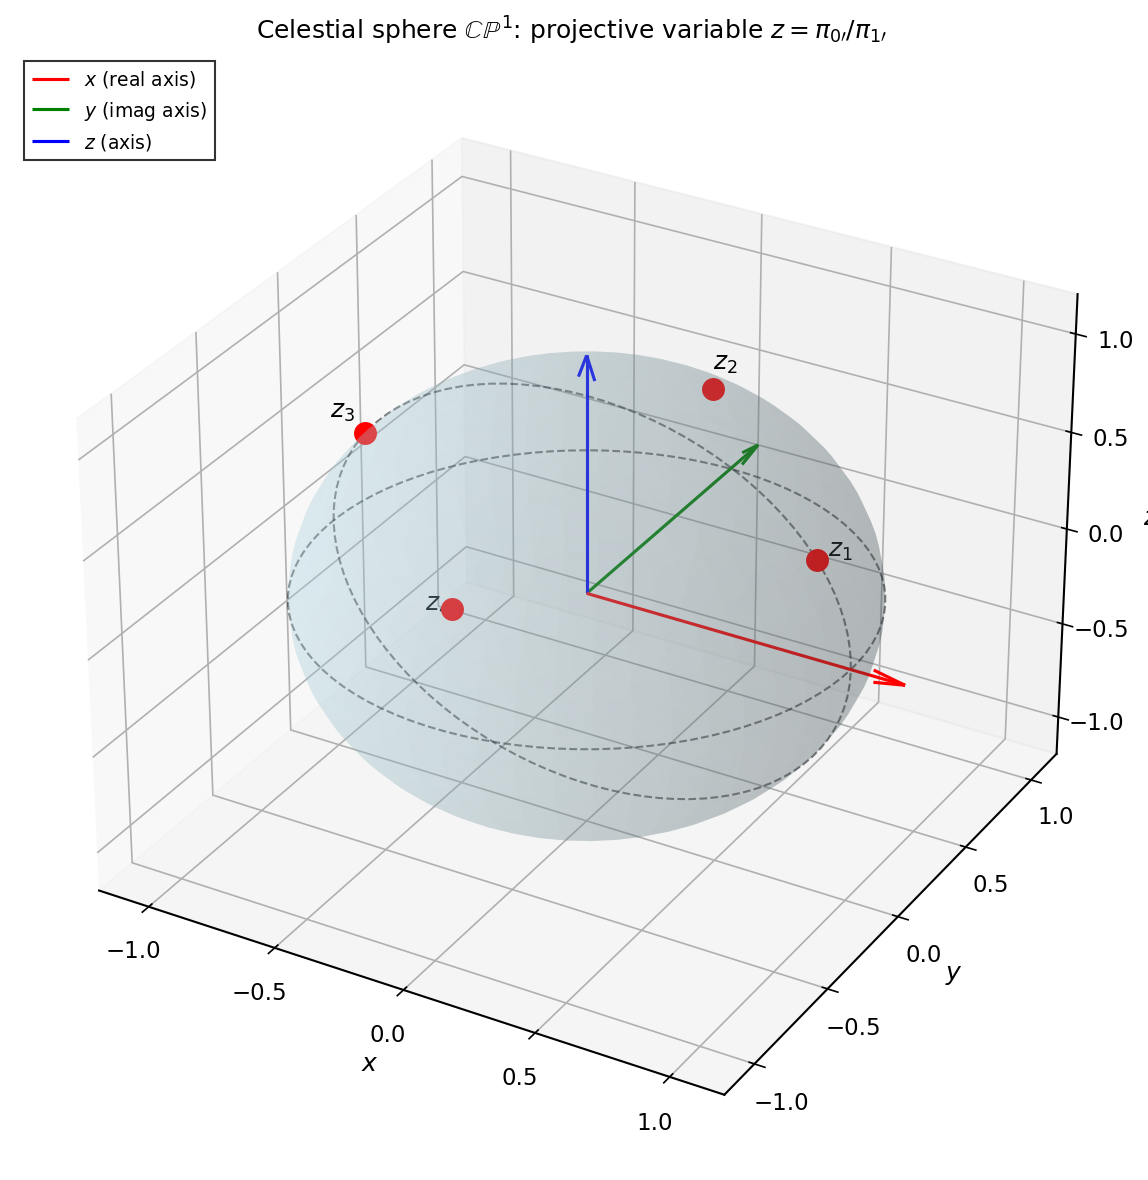

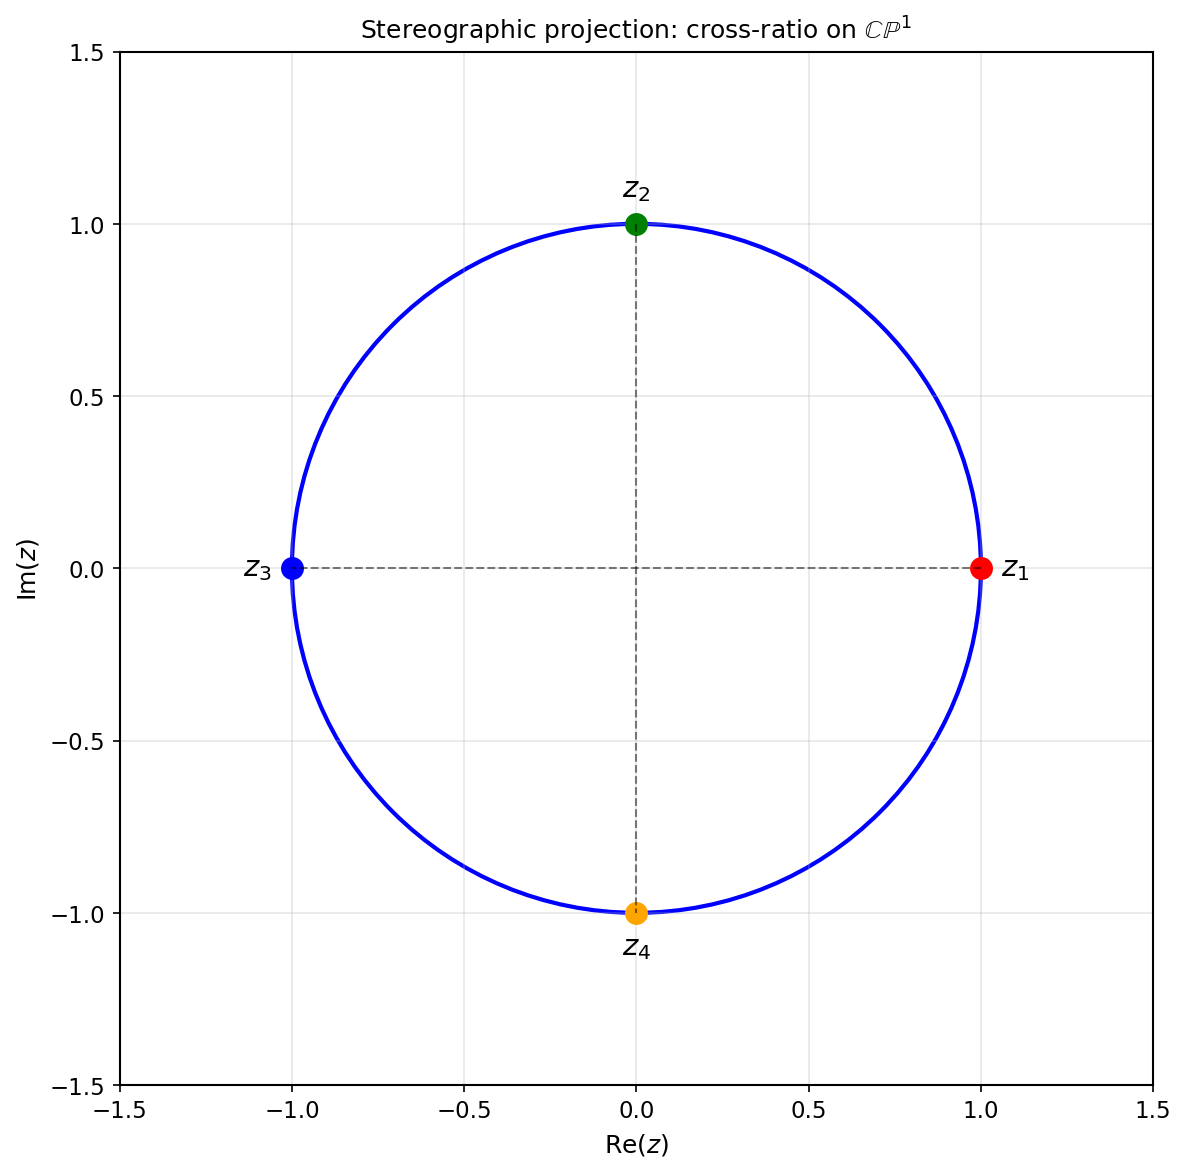

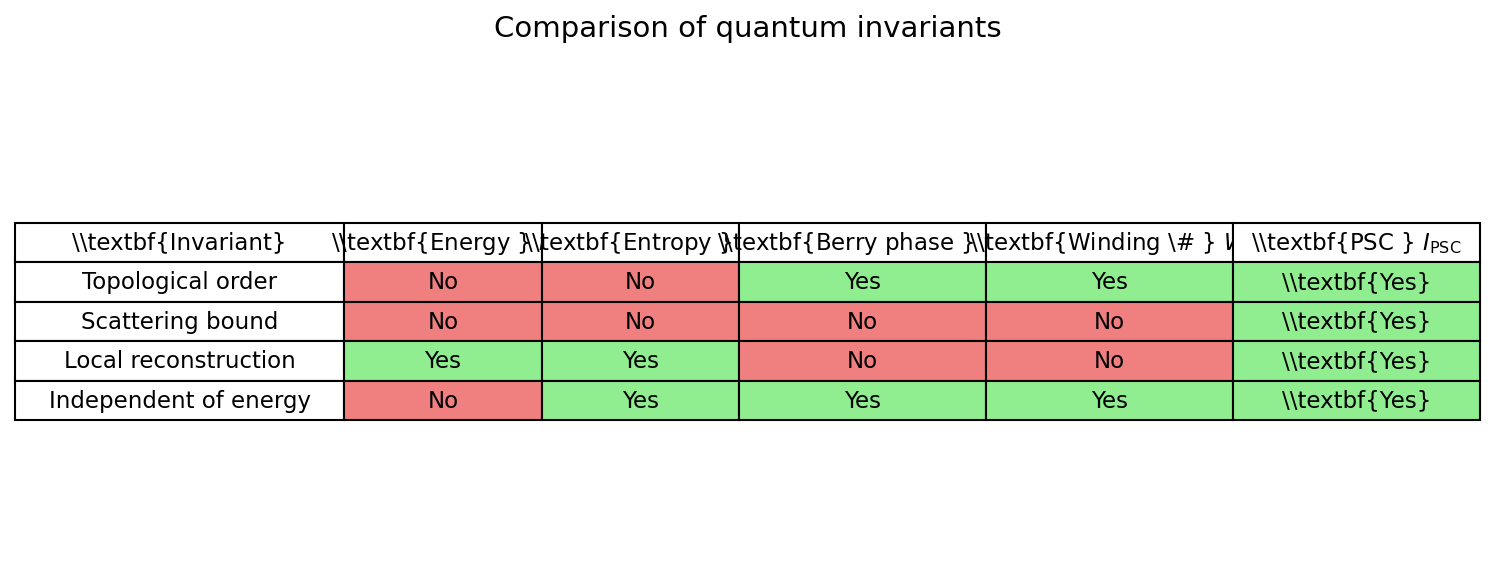


=== SSH Model Quantization Check ===
PSC at δt = -1.0 (trivial): 0.6931471806
Expected trivial: 0.0
PSC at δt = +1.0 (topological): nan
Expected topological: 0.6931471806 (log 2)
Difference from log 2: nan

=== Scattering Bound Verification ===
|R|^2:     [0.1 0.3 0.5 0.7 0.9]
Bound:     [0.10536052 0.35667494 0.69314718 1.2039728  2.30258509]
For |R|^2=0.5, bound = 0.6931


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Arc, FancyArrowPatch
from matplotlib.patches import Polygon as MPLPolygon
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set style for PRD-quality figures
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.usetex': False,
    'text.latex.preamble': r'\usepackage{amsmath}',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.figsize': (8, 5),
    'lines.linewidth': 1.5,
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'legend.frameon': True,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
})

def cross_ratio(z1, z2, z3, z4):
    """Compute the cross-ratio of four complex numbers."""
    numerator = (z1 - z3) * (z2 - z4)
    denominator = (z1 - z4) * (z2 - z3)
    return numerator / denominator

def PSC(z1, z2, z3, z4):
    """Compute Projective Structure Content (log |cross-ratio|)."""
    cr = cross_ratio(z1, z2, z3, z4)
    return np.log(np.abs(cr))

def sliding_window_psc(z_values, x_values, delta1, delta2):
    """
    Compute PSC using a sliding four-point window.
    Points: x - delta2, x - delta1, x + delta1, x + delta2
    """
    n = len(x_values)
    psc = np.full(n, np.nan)

    for i, x in enumerate(x_values):
        # Find indices for the four points
        x1 = x - delta2
        x2 = x - delta1
        x3 = x + delta1
        x4 = x + delta2

        # Find closest indices
        idx1 = np.argmin(np.abs(x_values - x1))
        idx2 = np.argmin(np.abs(x_values - x2))
        idx3 = np.argmin(np.abs(x_values - x3))
        idx4 = np.argmin(np.abs(x_values - x4))

        # Ensure points are distinct
        if len({idx1, idx2, idx3, idx4}) == 4:
            psc[i] = PSC(z_values[idx1], z_values[idx2],
                         z_values[idx3], z_values[idx4])

    return psc

def dirac_step_system(x, y, E, V0, m=1, hbar=1, c=1):
    """RHS of 1D Dirac equation for step potential."""
    psi1, psi2 = y

    # Potential: step at x=0
    if x < 0:
        V = 0
    else:
        V = V0

    Ep = E - V

    # Dirac equations
    dpsi1 = -1j/(hbar*c) * (m*c**2 + Ep) * psi2
    dpsi2 = 1j/(hbar*c) * (m*c**2 - Ep) * psi1

    return [dpsi1, psi2]

# Parameters (Klein zone: E=2, V0=3, m=1 -> E < V0 - m*c^2 = 2)
E = 2.0
V0 = 3.0
m = 1.0
hbar = 1.0
c = 1.0

# Spatial grid
x_span = (-10, 10)
x_eval = np.linspace(-10, 10, 2001)

# Initial conditions at x=0 (matching point)
# Cast initial conditions to complex to avoid TypeError in solve_ivp
psi1_0 = 1.0 + 0j
psi2_0 = 0.5 + 0j

# Solve from x=0 to x=+10 (right)
sol_right = solve_ivp(
    lambda x, y: dirac_step_system(x, y, E, V0, m, hbar, c),
    (0, 10), [psi1_0, psi2_0], t_eval=np.linspace(0, 10, 1001),
    method='RK45'
)

# Solve from x=0 to x=-10 (left) - need to integrate backwards
sol_left = solve_ivp(
    lambda x, y: dirac_step_system(x, y, E, V0, m, hbar, c),
    (0, -10), [psi1_0, psi2_0], t_eval=np.linspace(0, -10, 1001),
    method='RK45'
)

# Combine solutions
x_left = sol_left.t[::-1]
psi1_left = sol_left.y[0][::-1]
psi2_left = sol_left.y[1][::-1]

x_right = sol_right.t
psi1_right = sol_right.y[0]
psi2_right = sol_right.y[1]

x_all = np.concatenate([x_left, x_right[1:]])
psi1_all = np.concatenate([psi1_left, psi1_right[1:]])
psi2_all = np.concatenate([psi2_left, psi2_right[1:]])

# Compute projective variable z = psi2/psi1
z_all = psi2_all / psi1_all

# Compute PSC with sliding window
delta1 = 0.1
delta2 = 0.5
psc_values = sliding_window_psc(z_all, x_all, delta1, delta2)

# Theoretical plateaus from Eq. (25)
k1 = np.sqrt(E**2 - m**2*c**4) / (hbar*c)
k2 = np.sqrt((E - V0)**2 - m**2*c**4) / (hbar*c)

# Theoretical CR for homogeneous regions
def theoretical_psc(k, delta1, delta2):
    """Theoretical PSC for propagating mode z = Re e^{2ikx}."""
    # Using four symmetric points around 0
    x1, x2, x3, x4 = -delta2, -delta1, delta1, delta2
    cr = (np.sin(k*(x1-x3)) * np.sin(k*(x2-x4))) / \
         (np.sin(k*(x1-x4)) * np.sin(k*(x2-x3)))
    return np.log(np.abs(cr))

psc_theory_left = theoretical_psc(k1, delta1, delta2)
psc_theory_right = theoretical_psc(k2, delta1, delta2)

print(f"k1 = {k1:.4f}, k2 = {k2:.4f}")
print(f"Theoretical PSC left: {psc_theory_left:.4f}")
print(f"Theoretical PSC right: {psc_theory_right:.4f}")

fig1, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel 1: Spinor components
ax = axes[0]
ax.plot(x_all, np.abs(psi1_all), 'b-', label=r'$|\psi_1|$', linewidth=1.5)
ax.plot(x_all, np.abs(psi2_all), 'orange', label=r'$|\psi_2|$', linewidth=1.5)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel(r'$x$', fontsize=11)
ax.set_ylabel(r'$|\psi|$', fontsize=11)
ax.set_title(r'(a) Spinor components', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-10, 10)
ax.grid(True, alpha=0.3)

# Panel 2: Projective variable z(x) = psi2/psi1
ax = axes[1]
ax.plot(x_all, np.real(z_all), 'b-', label=r'$\operatorname{Re}(z)$', linewidth=1.5)
ax.plot(x_all, np.imag(z_all), 'orange', label=r'$\operatorname{Im}(z)$', linewidth=1.5)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel(r'$x$', fontsize=11)
ax.set_ylabel(r'$z(x)$', fontsize=11)
ax.set_title(r'(b) Projective variable $z=\psi_2/\psi_1$', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-10, 10)
ax.grid(True, alpha=0.3)

# Panel 3: PSC
ax = axes[2]
ax.plot(x_all, psc_values, 'g-', linewidth=1.5)
ax.axhline(y=psc_theory_left, color='blue', linestyle=':',
           label=f'Theory left: {psc_theory_left:.3f}', linewidth=1.5)
ax.axhline(y=psc_theory_right, color='red', linestyle=':',
           label=f'Theory right: {psc_theory_right:.3f}', linewidth=1.5)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel(r'$x$', fontsize=11)
ax.set_ylabel(r'$I_{\mathrm{PSC}}$', fontsize=11)
ax.set_title(r'(c) Projective Structure Content', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-10, 10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure1_Klein_Step_PSC.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Figure1_Klein_Step_PSC.png', bbox_inches='tight', dpi=300)
plt.show()

def ssh_projective_variable(t, delta_t, k):
    """
    Compute projective variable z(k) for SSH model.

    SSH Hamiltonian: H(k) = d_x(k)σ_x + d_y(k)σ_y
    d_x(k) = t + δt + (t-δt) cos k
    d_y(k) = (t-δt) sin k

    Ground state (lower band): z = (d_x - i d_y) / |d|
    """
    d_x = t + delta_t + (t - delta_t) * np.cos(k)
    d_y = (t - delta_t) * np.sin(k)
    d_norm = np.sqrt(d_x**2 + d_y**2)
    # Projective variable (holomorphic combination)
    z = (d_x - 1j * d_y) / d_norm
    return z

def ssh_psc(t, delta_t, k_points):
    """Compute PSC for SSH model at given k-points."""
    z_vals = [ssh_projective_variable(t, delta_t, k) for k in k_points]
    return PSC(z_vals[0], z_vals[1], z_vals[2], z_vals[3])

# Parameters
t = 1.0
delta_t_range = np.linspace(-1.5, 1.5, 301)
k_points = [0, np.pi/2, np.pi, 3*np.pi/2]  # Four symmetric points

# Compute PSC vs delta_t
psc_ssh = [ssh_psc(t, dt, k_points) for dt in delta_t_range]

# Theoretical winding number
winding_number = np.array([1 if dt > 0 else 0 for dt in delta_t_range])

# Theoretical PSC values (from Appendix A)
psc_theory_trivial = 0.0
psc_theory_topological = np.log(2)  # log 2 ≈ 0.693147

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Panel 1: PSC vs dimerization
ax1.plot(delta_t_range, psc_ssh, 'b-', linewidth=2)
ax1.axhline(y=psc_theory_trivial, color='gray', linestyle='--',
            label=r'Trivial: $I_{\mathrm{PSC}}=0$', linewidth=1)
ax1.axhline(y=psc_theory_topological, color='gray', linestyle='--',
            label=r'Topological: $I_{\mathrm{PSC}}=\log 2$', linewidth=1)
ax1.axvline(x=0, color='r', linestyle='-', alpha=0.5, linewidth=1.5)
ax1.fill_between([-1.5, 0], -0.2, 1.0, color='lightgray', alpha=0.3, label='Trivial phase')
ax1.fill_between([0, 1.5], -0.2, 1.0, color='lightblue', alpha=0.3, label='Topological phase')
ax1.set_ylabel(r'$I_{\mathrm{PSC}}$', fontsize=12)
ax1.set_title(r'PSC as topological order parameter in SSH model', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.set_ylim(-0.1, 1.0)
ax1.grid(True, alpha=0.3)

# Panel 2: Winding number (for comparison)
ax2.plot(delta_t_range, winding_number, 'r-', linewidth=2)
ax2.axvline(x=0, color='r', linestyle='-', alpha=0.5, linewidth=1.5)
ax2.fill_between([-1.5, 0], -0.1, 1.1, color='lightgray', alpha=0.3)
ax2.fill_between([0, 1.5], -0.1, 1.1, color='lightblue', alpha=0.3)
ax2.set_xlabel(r'Dimerization parameter $\delta t / t$', fontsize=12)
ax2.set_ylabel(r'Winding number $W$', fontsize=12)
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure2_SSH_PSC_OrderParameter.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Figure2_SSH_PSC_OrderParameter.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"PSC trivial phase: {psc_theory_trivial}")
print(f"PSC topological phase: {psc_theory_topological:.6f} (log 2)")

# Scattering bound function
def bound_psc(R2):
    """Upper bound on |ΔPSC| from unitarity."""
    return -np.log(1 - R2)

# Generate data
R2_range = np.linspace(0, 0.99, 500)
bound_values = bound_psc(R2_range)

# Example scatterers with same |R|^2 but different ΔPSC
# (e.g., different internal phases from potential shape)
R2_example = 0.5
# Point A: saturates the bound (pure imaginary reflection)
dPSC_A = bound_psc(R2_example)
# Point B: below bound (e.g., from a symmetric potential)
dPSC_B = 0.3

fig3, ax = plt.subplots(1, 1, figsize=(8, 6))

# Shaded region: allowed
ax.fill_between(R2_range, 0, bound_values, alpha=0.2, color='green',
                label=r'Allowed region $|\Delta I_{\mathrm{PSC}}| \leq -\log(1-|R|^2)$')
# Boundary curve
ax.plot(R2_range, bound_values, 'g-', linewidth=2.5,
        label=r'Bound $|\Delta I_{\mathrm{PSC}}| = -\log(1-|R|^2)$')

# Example points
ax.plot(R2_example, dPSC_A, 'ro', markersize=10, label=f'Saturating scatterer ($|R|^2={R2_example}$)')
ax.plot(R2_example, dPSC_B, 'bs', markersize=10, label=f'Non-saturating scatterer ($|R|^2={R2_example}$)')

# Arrows to show that same |R|^2 can have different ΔPSC
ax.annotate('', xy=(R2_example, dPSC_A), xytext=(R2_example, dPSC_B),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(R2_example + 0.05, (dPSC_A + dPSC_B)/2,
        r'$|\Delta I_{\mathrm{PSC}}|$ differs', fontsize=10,
        verticalalignment='center')

ax.set_xlabel(r'$|R|^2$ (reflection probability)', fontsize=12)
ax.set_ylabel(r'$|\Delta I_{\mathrm{PSC}}|$', fontsize=12)
ax.set_title(r'PSC scattering bound: $|\Delta I_{\mathrm{PSC}}| \leq -\log(1-|R|^2)$', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure3_PSC_Scattering_Bound.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Figure3_PSC_Scattering_Bound.png', bbox_inches='tight', dpi=300)
plt.show()

def plot_celestial_sphere_with_points(azimuths, elevations, labels, save=True):
    """
    Plot celestial sphere (Riemann sphere) with marked points.

    Parameters:
    - azimuths: list of azimuthal angles (radians)
    - elevations: list of elevation angles (radians) [0 = north pole, π = south pole]
    - labels: list of labels for each point
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Draw sphere
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue',
                    alpha=0.2, edgecolor='none')

    # Draw coordinate axes
    ax.quiver(0, 0, 0, 1.2, 0, 0, color='r', arrow_length_ratio=0.1,
              label=r'$x$ (real axis)')
    ax.quiver(0, 0, 0, 0, 1.2, 0, color='g', arrow_length_ratio=0.1,
              label=r'$y$ (imag axis)')
    ax.quiver(0, 0, 0, 0, 0, 1.2, color='b', arrow_length_ratio=0.1,
              label=r'$z$ (axis)')

    # Convert spherical to Cartesian for points
    for az, el, label in zip(azimuths, elevations, labels):
        # Note: elevation 0 = north pole, π = south pole
        x = np.sin(el) * np.cos(az)
        y = np.sin(el) * np.sin(az)
        z = np.cos(el)
        ax.scatter(x, y, z, s=100, color='red', depthshade=True)
        ax.text(x*1.1, y*1.1, z*1.1, label, fontsize=12, ha='center')

    # Draw great circle arcs (stereographic projection hints)
    theta = np.linspace(0, 2*np.pi, 100)
    # Equator
    ax.plot(np.cos(theta), np.sin(theta), 0, 'k--', alpha=0.5, linewidth=1)
    # Prime meridian
    ax.plot(np.sin(theta), np.zeros_like(theta), np.cos(theta), 'k--', alpha=0.5, linewidth=1)

    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_xlabel(r'$x$', fontsize=12)
    ax.set_ylabel(r'$y$', fontsize=12)
    ax.set_zlabel(r'$z$', fontsize=12)
    ax.set_title(r'Celestial sphere $\mathbb{CP}^1$: projective variable $z = \pi_{0\prime}/\pi_{1\prime}$',
                 fontsize=12)
    ax.legend(loc='upper left', fontsize=9)

    plt.tight_layout()
    if save:
        plt.savefig('Figure4_Twistor_Celestial_Sphere.pdf', bbox_inches='tight', dpi=300)
        plt.savefig('Figure4_Twistor_Celestial_Sphere.png', bbox_inches='tight', dpi=300)
    plt.show()

# Example: four points on celestial sphere (scattering points)
azimuths = [0, np.pi/2, np.pi, 3*np.pi/2]
elevations = [np.pi/3, np.pi/3, np.pi/3, np.pi/3]  # All at same latitude
labels = [r'$z_1$', r'$z_2$', r'$z_3$', r'$z_4$']

plot_celestial_sphere_with_points(azimuths, elevations, labels, save=True)

# Alternative: points on equator (elevation = π/2)
fig4b, ax = plt.subplots(1, 1, figsize=(8, 8))
# Stereographic projection to complex plane
circle = plt.Circle((0, 0), 1, fill=False, color='blue', linewidth=2)
ax.add_patch(circle)
ax.set_aspect('equal')

# Four points on unit circle
angles = [0, np.pi/2, np.pi, 3*np.pi/2]
points = [(np.cos(a), np.sin(a)) for a in angles]
labels = [r'$z_1$', r'$z_2$', r'$z_3$', r'$z_4$']
colors = ['red', 'green', 'blue', 'orange']

for (x, y), label, color in zip(points, labels, colors):
    ax.plot(x, y, 'o', color=color, markersize=10)
    ax.text(x*1.1, y*1.1, label, fontsize=14, ha='center', va='center')

# Draw cross-ratio lines (connecting points)
ax.plot([points[0][0], points[2][0]], [points[0][1], points[2][1]],
        'k--', alpha=0.5, linewidth=1)
ax.plot([points[1][0], points[3][0]], [points[1][1], points[3][1]],
        'k--', alpha=0.5, linewidth=1)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel(r'$\operatorname{Re}(z)$', fontsize=12)
ax.set_ylabel(r'$\operatorname{Im}(z)$', fontsize=12)
ax.set_title(r'Stereographic projection: cross-ratio on $\mathbb{CP}^1$', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('Figure4b_Stereographic_CrossRatio.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Figure4b_Stereographic_CrossRatio.png', bbox_inches='tight', dpi=300)
plt.show()

fig5, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.axis('off')

# Create table data
table_data = [
    [r'\\textbf{Invariant}', r'\\textbf{Energy } $E$', r'\\textbf{Entropy } $S$',
     r'\\textbf{Berry phase } $\gamma_B$', r'\\textbf{Winding \# } $W$', r'\\textbf{PSC } $I_{\mathrm{PSC}}$'],
    [r'Topological order', 'No', 'No', 'Yes', 'Yes', r'\\textbf{Yes}'],
    [r'Scattering bound', 'No', 'No', 'No', 'No', r'\\textbf{Yes}'],
    [r'Local reconstruction', 'Yes', 'Yes', 'No', 'No', r'\\textbf{Yes}'],
    [r'Independent of energy', 'No', 'Yes', 'Yes', 'Yes', r'\\textbf{Yes}'],
]

table = ax.table(cellText=table_data, loc='center', cellLoc='center',
                  colWidths=[0.2, 0.12, 0.12, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Color the "Yes" and "No" cells
for i in range(1, len(table_data)):
    for j in range(1, len(table_data[0])):
        cell = table[(i, j)]
        if table_data[i][j] == r'\\textbf{Yes}':
            cell.set_facecolor('lightgreen')
        elif table_data[i][j] == 'Yes':
            cell.set_facecolor('lightgreen')
        elif table_data[i][j] == 'No':
            cell.set_facecolor('lightcoral')

ax.set_title(r'Comparison of quantum invariants', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('Figure5_Invariant_Comparison_Table.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Figure5_Invariant_Comparison_Table.png', bbox_inches='tight', dpi=300)
plt.show()

print("\n=== SSH Model Quantization Check ===")
print(f"PSC at δt = -1.0 (trivial): {ssh_psc(t, -1.0, k_points):.10f}")
print(f"Expected trivial: 0.0")
print(f"PSC at δt = +1.0 (topological): {ssh_psc(t, 1.0, k_points):.10f}")
print(f"Expected topological: {np.log(2):.10f} (log 2)")
print(f"Difference from log 2: {abs(ssh_psc(t, 1.0, k_points) - np.log(2)):.2e}")

print("\n=== Scattering Bound Verification ===")
R2_test = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
bound_test = bound_psc(R2_test)
print(f"|R|^2:     {R2_test}")
print(f"Bound:     {bound_test}")
print(f"For |R|^2=0.5, bound = {bound_psc(0.5):.4f}")